# FIN-RoBERTa vs FinBERT — Model Comparison

Side-by-side evaluation of **FIN-RoBERTa** (custom) and **FinBERT** (baseline) on the Financial PhraseBank dataset (sentences_allagree — 100% annotator agreement).

In [7]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score
)
from datasets import load_dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Load both models for comparison
models = {}
for name, hf_id in [("FIN-RoBERTa", "alasteirho/FIN-RoBERTa-Custom"), ("FinBERT", "ProsusAI/finbert")]:
    print(f"Loading {name}")
    tok = AutoTokenizer.from_pretrained(hf_id)
    mdl = AutoModelForSequenceClassification.from_pretrained(hf_id).to(device).eval()
    models[name] = {"tokenizer": tok, "model": mdl}
print("All models loaded.")

Device: cuda
Loading FIN-RoBERTa


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading FinBERT


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


All models loaded.


In [8]:
# ======== Load dataset ========
dataset = load_dataset("takala/financial_phrasebank", "sentences_allagree")
df = pd.DataFrame(dataset["train"])
df["sentiment"] = df["label"].map({0: "negative", 1: "neutral", 2: "positive"})
print(f"Dataset: {len(df)} samples")
print(df["sentiment"].value_counts())

# ======== Label maps per model ========
# Maps model output index to canonical label, and canonical label to model index.
# The inverse map is needed so that when we pass labels to the HF model's forward
# pass, the indices match each model's native label ordering (otherwise HF's
# internal CrossEntropyLoss will produce a meaningless loss value).
LABEL_MAPS = {
    "FIN-RoBERTa": {0: "negative", 1: "neutral", 2: "positive"},
    "FinBERT":     {0: "positive", 1: "negative", 2: "neutral"},
}
INVERSE_LABEL_MAPS = {
    name: {label: idx for idx, label in idx_to_label.items()}
    for name, idx_to_label in LABEL_MAPS.items()
}

# ======== Run predictions for both models ========
# Loss computation matches the methodology of Ergun & Sefer (2025): each batch's
# labels are passed through the HuggingFace forward pass so that the model's own
# internal CrossEntropyLoss computes the mean per-batch loss (HF default
# reduction="mean"). The per-batch loss is then re-weighted by batch size and
# averaged across the dataset, giving the same mean per-sample cross-entropy
# loss they report:  total_loss / n_samples.
BATCH_SIZE = 32
y_true = df["sentiment"].astype(str).str.lower()
all_preds = {}
all_losses = {}

sentences = df["sentence"].astype(str).tolist()

for name, m in models.items():
    tok, mdl, lmap = m["tokenizer"], m["model"], LABEL_MAPS[name]
    inv_lmap = INVERSE_LABEL_MAPS[name]
    # Ground-truth indices in this model's native label ordering
    native_label_indices = y_true.map(inv_lmap).astype(int).tolist()

    preds = []
    total_loss = 0.0
    total_n = 0

    n_batches = (len(sentences) + BATCH_SIZE - 1) // BATCH_SIZE
    for b in tqdm(range(n_batches), desc=name):
        start = b * BATCH_SIZE
        end = min(start + BATCH_SIZE, len(sentences))
        batch_texts = sentences[start:end]
        batch_labels = torch.tensor(
            native_label_indices[start:end], dtype=torch.long, device=device
        )

        inputs = tok(
            batch_texts,
            return_tensors="pt",
            truncation=True,
            max_length=512,
            padding=True,
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}
        inputs["labels"] = batch_labels

        with torch.no_grad():
            out = mdl(**inputs)

        # HF computes mean-per-sample CE loss when labels are provided.
        # Re-weight by batch size to accumulate the sum, then divide by n.
        batch_size_actual = batch_labels.size(0)
        total_loss += float(out.loss.item()) * batch_size_actual
        total_n += batch_size_actual

        batch_pred_indices = torch.argmax(out.logits, dim=-1).tolist()
        preds.extend(lmap[idx] for idx in batch_pred_indices)

    mean_loss = total_loss / total_n
    all_preds[name] = preds
    all_losses[name] = mean_loss
    print(f"{name}  accuracy={accuracy_score(y_true, preds):.4f}  loss={mean_loss:.4f}\n")

Using the latest cached version of the dataset since takala/financial_phrasebank couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'sentences_allagree' at C:\Users\Alasteir\.cache\huggingface\datasets\takala___financial_phrasebank\sentences_allagree\0.0.0\0dd3028d70cbd18ded8887e65e83343b03a50482 (last modified on Tue Jan 27 01:23:32 2026).


Dataset: 2264 samples
sentiment
neutral     1391
positive     570
negative     303
Name: count, dtype: int64


FIN-RoBERTa: 100%|██████████| 71/71 [00:01<00:00, 48.41it/s]


FIN-RoBERTa  accuracy=0.9929  loss=0.0302



FinBERT: 100%|██████████| 71/71 [00:01<00:00, 54.22it/s]

FinBERT  accuracy=0.9717  loss=0.1316



## Classification Reports

In [9]:
labels = ["positive", "neutral", "negative"]

for name, preds in all_preds.items():
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(classification_report(y_true, preds, digits=3))


FIN-RoBERTa
              precision    recall  f1-score   support

    negative      0.987     0.993     0.990       303
     neutral      0.995     0.996     0.996      1391
    positive      0.991     0.984     0.988       570

    accuracy                          0.993      2264
   macro avg      0.991     0.991     0.991      2264
weighted avg      0.993     0.993     0.993      2264


FinBERT
              precision    recall  f1-score   support

    negative      0.906     0.983     0.943       303
     neutral      0.999     0.967     0.982      1391
    positive      0.947     0.977     0.962       570

    accuracy                          0.972      2264
   macro avg      0.951     0.976     0.963      2264
weighted avg      0.973     0.972     0.972      2264



## Metrics Comparison

              Loss  Accuracy  Macro F1  Macro Precision  Macro Recall
FIN-RoBERTa 0.0302    0.9929    0.9912           0.9910        0.9913
FinBERT     0.1316    0.9717    0.9625           0.9505        0.9759


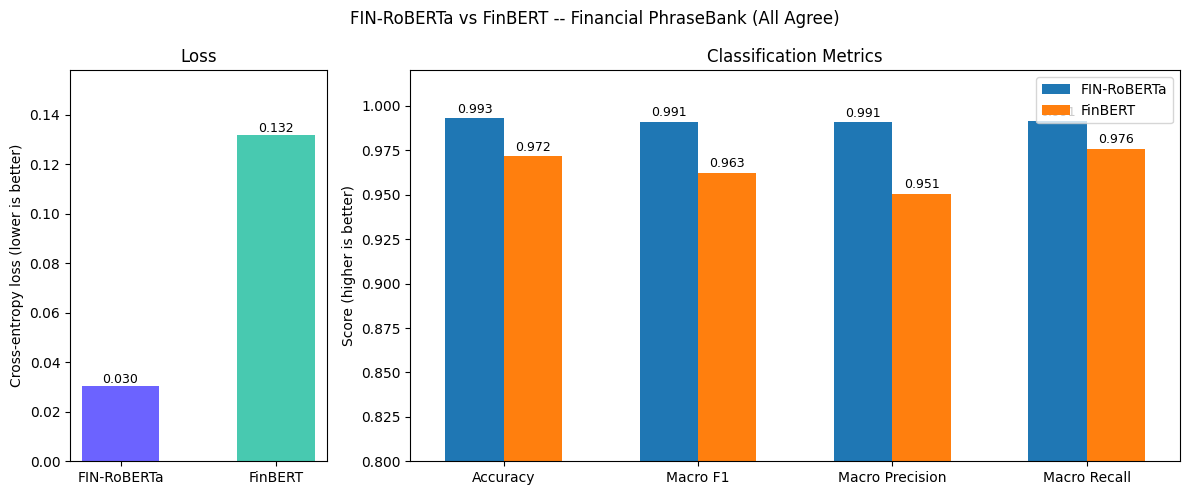

In [10]:
# Comparison table (matches Report Table 3.1 format: Loss, Accuracy, F1 + macro P/R)
metrics = {}
for name, preds in all_preds.items():
    metrics[name] = {
        "Loss":            all_losses[name],
        "Accuracy":        accuracy_score(y_true, preds),
        "Macro F1":        f1_score(y_true, preds, average="macro"),
        "Macro Precision": precision_score(y_true, preds, average="macro"),
        "Macro Recall":    recall_score(y_true, preds, average="macro"),
    }

comparison_df = pd.DataFrame(metrics).T
print(comparison_df.to_string(float_format=lambda x: f"{x:.4f}"))

# Bar chart: two panels because Loss is on a different scale from the 0-1 metrics
score_cols = ["Accuracy", "Macro F1", "Macro Precision", "Macro Recall"]

fig, (ax_loss, ax_scores) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1, 3]})

# --- Left panel: Loss (lower is better) ---
model_names = list(comparison_df.index)
loss_values = comparison_df["Loss"].values
bars = ax_loss.bar(np.arange(len(model_names)), loss_values, width=0.5, color=["#6C63FF", "#48C9B0"])
for i, v in enumerate(loss_values):
    ax_loss.text(i, v + max(loss_values) * 0.01, f"{v:.3f}", ha="center", fontsize=9)
ax_loss.set_ylabel("Cross-entropy loss (lower is better)")
ax_loss.set_title("Loss")
ax_loss.set_xticks(np.arange(len(model_names)))
ax_loss.set_xticklabels(model_names)
ax_loss.set_ylim(0, max(loss_values) * 1.2)

# --- Right panel: Accuracy / F1 / Precision / Recall ---
x = np.arange(len(score_cols))
width = 0.3
for i, (model_name, row) in enumerate(comparison_df.iterrows()):
    values = row[score_cols].values
    bars = ax_scores.bar(x + i * width, values, width, label=model_name)
    for j, v in enumerate(values):
        ax_scores.text(x[j] + i * width, v + 0.003, f"{v:.3f}", ha="center", fontsize=9)

ax_scores.set_ylabel("Score (higher is better)")
ax_scores.set_title("Classification Metrics")
ax_scores.set_xticks(x + width / 2)
ax_scores.set_xticklabels(score_cols)
ax_scores.set_ylim(0.8, 1.02)
ax_scores.legend()

fig.suptitle("FIN-RoBERTa vs FinBERT -- Financial PhraseBank (All Agree)")
plt.tight_layout()
plt.show()

## Confusion Matrices

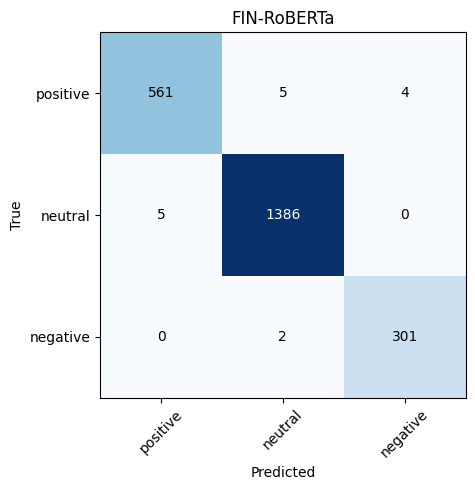

In [11]:
# FIN-RoBERTa Confusion Matrix
cm = confusion_matrix(y_true, all_preds["FIN-RoBERTa"], labels=labels)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45)
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("FIN-RoBERTa")
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.show()

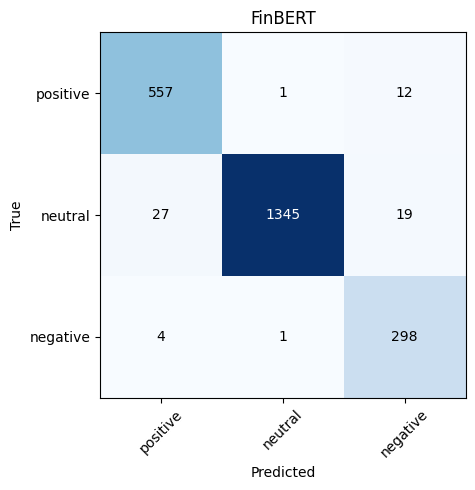

In [12]:
# FinBERT Confusion Matrix
cm = confusion_matrix(y_true, all_preds["FinBERT"], labels=labels)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45)
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("FinBERT")
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.show()